In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from diffusion_brain_alignment.data.fmri_laion.download import download, init_config

init_config()

In [8]:
download(subject="sub-01", session="ses-01")

[laion-fmri] stimuli already up to date.


In [10]:
from laion_fmri.subject import load_subject

sub = load_subject(subject="sub-01")
df = sub.get_trial_info(session="ses-01")

In [ ]:
df

In [20]:
sub.metadata[sub.metadata['unique_or_shared']== 'shared'].drop_duplicates()["session_trial"].values[:100]

array([  2,   5,   6,   7,   8,  10,  13,  14,  17,  19,  22,  26,  27,
        30,  31,  32,  33,  37,  40,  41,  43,  46,  47,  49,  52,  53,
        57,  58,  59,  60,  62,  63,  64,  66,  68,  69,  70,  71,  73,
        76,  77,  78,  79,  80,  84,  85,  86,  87,  90,  91,  94,  96,
        99, 100, 103, 107, 108, 110, 115, 116, 120, 121, 124, 127, 131,
       133, 136, 138, 140, 143, 144, 145, 146, 147, 148, 149, 151, 154,
       165, 166, 167, 168, 169, 172, 175, 176, 183, 185, 197, 198, 199,
       200, 202, 204, 205, 206, 209, 215, 218, 219])

In [22]:
sub.metadata[(sub.metadata['unique_or_shared']== 'shared') & (sub.metadata['session']== 'ses-01')].drop_duplicates()

,session,run,beta_index,label,session_trial,image_name,stim_idx,unique_or_shared,dataset
2,ses-01,1,2,shared_12rep_LAION_cluster_2677_i5.jpg,2,shared_12rep_LAION_cluster_2677_i5.jpg,259,shared,LAION
5,ses-01,1,5,shared_12rep_LAION_cluster_1212_i0.jpg,5,shared_12rep_LAION_cluster_1212_i0.jpg,36,shared,LAION
6,ses-01,1,6,shared_12rep_LAION_cluster_3335_i0.jpg,6,shared_12rep_LAION_cluster_3335_i0.jpg,354,shared,LAION
7,ses-01,1,7,shared_12rep_LAION_cluster_861_i1.jpg,7,shared_12rep_LAION_cluster_861_i1.jpg,628,shared,LAION
8,ses-01,1,8,shared_4rep_OOD_illusion-natural_piano-fence.jpg,8,shared_4rep_OOD_illusion-natural_piano-fence.jpg,1243,shared,OOD
...,...,...,...,...,...,...,...,...,...
1036,ses-01,12,79,shared_12rep_LAION_cluster_2442_i1.jpg,1036,shared_12rep_LAION_cluster_2442_i1.jpg,229,shared,LAION
1037,ses-01,12,80,shared_12rep_LAION_cluster_3644_i5.jpg,1037,shared_12rep_LAION_cluster_3644_i5.jpg,397,shared,LAION
1038,ses-01,12,81,shared_12rep_LAION_cluster_1065_i4.jpg,1038,shared_12rep_LAION_cluster_1065_i4.jpg,12,shared,LAION
1039,ses-01,12,82,shared_12rep_LAION_cluster_1227_i5.jpg,1039,shared_12rep_LAION_cluster_1227_i5.jpg,39,shared,LAION


In [54]:
from diffusion_brain_alignment.data.fmri_laion.download import sample_trials

trails = sample_trials(subject="sub-01", session="ses-01", n_samples=10)
trails

{'subject': 'sub-01',
 'session': 'ses-01',
 'trials': [2, 5, 6, 7, 8, 10, 13, 14, 17, 19]}

In [57]:
sub.metadata['image_name'].values[trails["trials"]]

array(['shared_12rep_LAION_cluster_2677_i5.jpg',
       'shared_12rep_LAION_cluster_1212_i0.jpg',
       'shared_12rep_LAION_cluster_3335_i0.jpg',
       'shared_12rep_LAION_cluster_861_i1.jpg',
       'shared_4rep_OOD_illusion-natural_piano-fence.jpg',
       'shared_12rep_LAION_cluster_4037_i1.jpg',
       'shared_12rep_LAION_cluster_3782_i0.jpg',
       'shared_12rep_THINGS+_kmeans_4_toothpick.jpg',
       'shared_12rep_LAION_cluster_1006_i0.jpg',
       'shared_12rep_LAION_cluster_3055_i1.jpg'], dtype=object)

In [44]:
from PIL import Image
import laion_fmri

stim = laion_fmri.load_stimuli()

some_image_names = sub.metadata['label'].drop_duplicates()

width = []
height = []

count_non_square = 0

for image_name in some_image_names:
    image = stim.images.get(image_name)
    width.append(image.width)
    height.append(image.height)
    count_non_square += 1 if image.width != image.height else 0
    
print(f"Number of non-square images: {count_non_square} out of {len(some_image_names)}")

Number of non-square images: 0 out of 769


In [ ]:
resized_image = image.resize((256, 256))


In [53]:
import numpy as np
np.array(image).shape

(1000, 1000, 3)

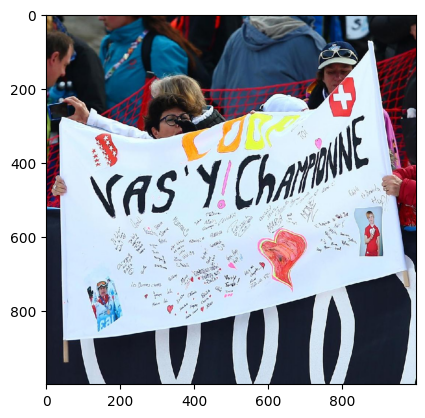

In [52]:
import matplotlib.pyplot as plt

plt.imshow(np.array(image))

In [31]:
import laion_fmri

stim = laion_fmri.load_stimuli()


In [32]:
stim.metadata

,image_name,dataset,participant,unique_or_shared,n_reps
0,shared_12rep_LAION_cluster_1003_i0.jpg,LAION,sub-01;sub-03;sub-05;sub-06;sub-07,shared,12rep
1,shared_12rep_LAION_cluster_1006_i0.jpg,LAION,sub-01;sub-03;sub-05;sub-06;sub-07,shared,12rep
2,shared_12rep_LAION_cluster_1011_i2.jpg,LAION,sub-01;sub-03;sub-05;sub-06;sub-07,shared,12rep
3,shared_12rep_LAION_cluster_1015_i1.jpg,LAION,sub-01;sub-03;sub-05;sub-06;sub-07,shared,12rep
4,shared_12rep_LAION_cluster_1018_i2.jpg,LAION,sub-01;sub-03;sub-05;sub-06;sub-07,shared,12rep
...,...,...,...,...,...
25047,shared_4rep_OOD_shape_color_simple_shapes_20-s...,OOD,sub-01;sub-03;sub-05;sub-06;sub-07,shared,4rep
25048,shared_4rep_OOD_shape_color_simple_shapes_21-s...,OOD,sub-01;sub-03;sub-05;sub-06;sub-07,shared,4rep
25049,shared_4rep_OOD_shape_color_simple_shapes_22-s...,OOD,sub-01;sub-03;sub-05;sub-06;sub-07,shared,4rep
25050,shared_4rep_OOD_shape_color_simple_shapes_23-s...,OOD,sub-01;sub-03;sub-05;sub-06;sub-07,shared,4rep


In [58]:
from diffusion_brain_alignment.data.fmri_laion.download import sample_trials, load_stimuli

trials = sample_trials(subject="sub-01", session="ses-01", n_samples=10)
images = load_stimuli(trials)


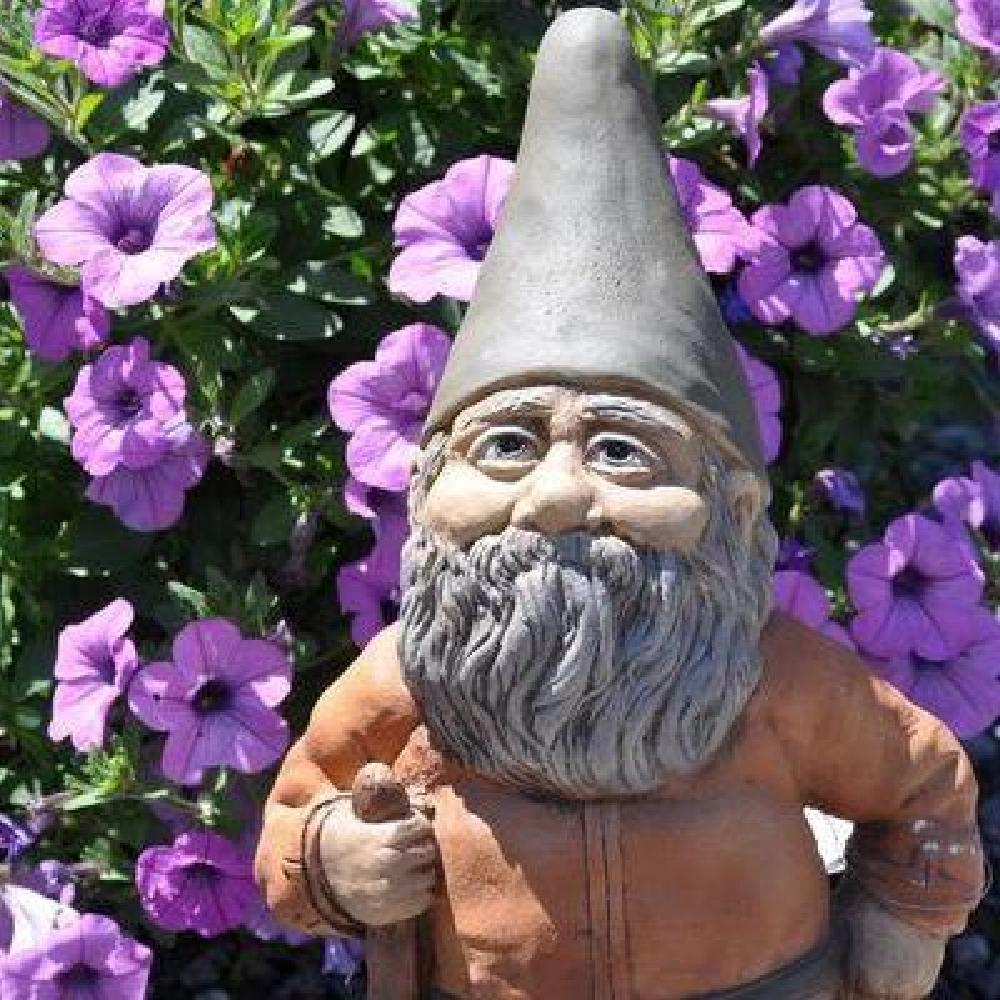

In [61]:
images[2]